# Define the Complete AgentState

# Implement Graph Nodes as Isolated Functions

## Node 1: Guardrail Node

In [2]:
from src.safety.guardrails import Guardrails

def run_guardrail_check(state: MedicalAgentState) -> Dict[str, Any]:
    print("🛡️ [Node: Guardrail] Inspecting input safety criteria...")
    guardrails = Guardrails()
    guardrail_result = guardrails.check_input(state["raw_query"])
    
    # Handle implicit None returns for perfectly safe queries
    if guardrail_result is None:
        return {"is_safe": True, "refusal_message": ""}
    
    is_safe, refusal_msg = guardrail_result
    return {"is_safe": is_safe, "refusal_message": refusal_msg}

## Node 2: Risk Classification Node

In [3]:
from src.safety.risk_classifier import RiskClassifier

def run_risk_classification(state: MedicalAgentState) -> Dict[str, Any]:
    print("⚠️ [Node: Classifier] Assessing clinical urgency tier...")
    classifier = RiskClassifier()
    risk_analysis = classifier.classify(state["raw_query"])
    return {"risk_level": risk_analysis.get("risk_level", "low")}

## Node 3: Multimodal Processing & Query Augmentation Node

In [4]:
from typing import Optional, Tuple, Dict, Any
from src.preprocessing.image_processor import MedicalImageProcessor

def coordinate_multimodal_query(user_text: str, image_input: Optional[Any] = None) -> Tuple[str, Dict[str, Any]]:
    """
    Processes an image input before database retrieval, extracting text features
    and augmenting the raw user text query so it remains completely text-compatible.
    """
    augmented_text = user_text
    image_metadata = {}
    
    if image_input is not None:
        print("📸 Image input detected. Activating MedicalImageProcessor...")
        
        # Initialize your processor with OCR explicitly turned on
        processor = MedicalImageProcessor(enhance_contrast=True, run_ocr=True)
        
        # Process the image (handles file paths, pathlib objects, or PIL images)
        processed_image = processor.process(image_input)
        
        # Capture generated structural metadata (modality, dimensions, etc.)
        image_metadata = processed_image.metadata
        
        # Text Augmentation Channel: Append OCR output directly into the query context
        if processed_image.extracted_text and processed_image.extracted_text.strip():
            print(f"🎯 OCR Text Extracted successfully ({len(processed_image.extracted_text)} chars)")
            augmented_text += f"\n\n[Context extracted from attached medical image/file]:\n{processed_image.extracted_text}"
        else:
            # Fallback for visual-only modalities (e.g., skin photos, wounds, x-rays) where OCR finds nothing
            print(f"🔍 No text found via OCR. Augmenting query with auto-detected modality: {processed_image.modality}")
            augmented_text += f"\n\n[Context: User attached a medical image classified as a clinical {processed_image.modality} photograph]"
            
    return augmented_text, image_metadata

In [5]:
def run_multimodal_processing(state: MedicalAgentState) -> Dict[str, Any]:
    print("📸 [Node: Multimodal] Extracting textual/visual indicators from image channel...")
    user_text = state["raw_query"]
    image_file = state["image_input"]
    
    # Re-use our coordinated helper function from yesterday
    final_search_query, img_meta = coordinate_multimodal_query(user_text, image_file)
    return {"augmented_query": final_search_query, "image_metadata": img_meta}

## Node 4: Vector Ingestion Retrieval Node

In [6]:
from src.rag.vector_store import MedicalVectorStore

def run_vector_search(state: MedicalAgentState) -> Dict[str, Any]:
    print("📡 [Node: Retriever] Fetching grounded documents from 1024-d Chroma collection...")
    vs = MedicalVectorStore()
    
    # Search using the augmented text string generated by the multimodal node
    search_query = state.get("augmented_query", state["raw_query"])
    docs = vs.similarity_search(query=search_query, k=3)
    return {"retrieved_docs": docs}

c:\santosh\MediGemma\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Node 5: Gemma 4 Offline Inference Generator Node

In [7]:
from langchain_ollama import OllamaLLM
from src.safety.guardrails import Guardrails

def run_gemma_generation(state: MedicalAgentState) -> Dict[str, Any]:
    # Route A: The input tripped an emergency keyword flag
    if state["risk_level"] == "emergency":
        print("🚨 [Node: Generator] Risk level is emergency! Constructing immediate escalation text.")
        emergency_text = (
            "⚠️ EMERGENCY DETECTED: If you or someone near you is experiencing severe symptoms "
            "like crushing chest pain, sudden numbness, or severe shortness of breath, please stop "
            "using this tool and call emergency services (like 911) immediately."
        )
        return {"generation": emergency_text, "final_output_with_disclaimer": emergency_text}
        
    print("🤖 [Node: Generator] Executing local offline grounding prompt stream via Ollama...")
    llm = OllamaLLM(model="gemma4:e2b", base_url="http://localhost:11434", temperature=0.2, num_predict=512)
    guardrails = Guardrails()
    
    # Format retrieved document context
    context_str = ""
    for idx, doc in enumerate(state.get("retrieved_docs", [])):
        source_name = doc.metadata.get("source", "Verified Clinical Guidance")
        context_str += f"\n[Reference Document {idx+1}] Source: {source_name}\n{doc.page_content}\n"
        
    system_prompt = f"""You are MediGemma, an expert, clinical-grade AI medical assistant running fully offline.
Your priority is patient safety and rigid adherence to verified medical protocols.

[CRITICAL GROUNDING INSTRUCTIONS]
- Answer the user's inquiry based strictly and exclusively on the medical context documents provided below.
- If the provided reference documents do not contain the answer, explicitly state: "I do not have enough verified clinical source data to confidently answer this question." 
- Never speculate, hallucinate, or extrapolate outside the provided reference text.

[GROUNDING REFERENCE MATERIAL]:
{context_str}

[PATIENT INPUT (Including extracted visual context)]:
{state.get('augmented_query', state['raw_query'])}

Please formulate your safe, grounded response now:"""

    try:
        model_response = llm.invoke(system_prompt)
        
        # Append the legal safety disclaimer text to the tail end of the response
        final_text = model_response
        if hasattr(guardrails, 'DISCLAIMER_TEXT') and guardrails.DISCLAIMER_TEXT:
            final_text += f"\n\n🛡️ MANDATORY SAFETY NOTICE:\n{guardrails.DISCLAIMER_TEXT}"
            
        return {"generation": model_response, "final_output_with_disclaimer": final_text}
    except Exception as e:
        error_msg = f"❌ Connection error: Could not communicate with local Ollama service. Error: {e}"
        return {"generation": error_msg, "final_output_with_disclaimer": error_msg}

# Build and Compile the Stateful LangGraph Topology

In [ ]:
from langgraph.graph import StateGraph, END
from IPython.display import display, Image

# Initialize state engine wrapper
workflow = StateGraph(MedicalAgentState)

# 1. Register operational nodes
workflow.add_node("guardrail", run_guardrail_check)
workflow.add_node("classifier", run_risk_classification)
workflow.add_node("multimodal_processor", run_multimodal_processing)
workflow.add_node("retriever", run_vector_search)
workflow.add_node("generator", run_gemma_generation)

# 2. Build explicit pipeline edge architecture
workflow.set_entry_point("guardrail")

# Route conditionally from Guardrail node based on script safety flag
def route_after_guardrail(state: MedicalAgentState):
    if not state["is_safe"]:
        print("🛑 Input flagged by safety policies. Routing directly to output termination.")
        return "generator"  # Will instantly skip RAG and return refusal text
    return "classifier"

workflow.add_conditional_edges("guardrail", route_after_guardrail)

# Route conditionally from Risk Classifier node based on context tier
def route_after_classification(state: MedicalAgentState):
    if state["risk_level"] == "emergency":
        print("🚨 Severe clinical urgency detected! Routing straight to Generator for bypass escalation.")
        return "generator"
    return "multimodal_processor"

workflow.add_conditional_edges("classifier", route_after_classification)

# Construct sequential linkages for clean inquiries
workflow.add_edge("multimodal_processor", "retriever")
workflow.add_edge("retriever", "generator")
workflow.add_edge("generator", END)

# Compile graph configuration
app = workflow.compile()
print("🕸️ LangGraph workflow compiled successfully!")


🕸️ LangGraph workflow compiled successfully!


# Test the Stateful Agent Loop

In [13]:
from PIL import Image, ImageDraw

# 1. Re-create the synthetic lab report image containing text data
mock_report = Image.new("RGB", (768, 1024), color=(255, 255, 255))
draw = ImageDraw.Draw(mock_report)

# Draw the mock clinical data onto the canvas
draw.text((50, 50), "LABORATORY REPORT", fill=(0, 0, 0))
draw.text((50, 100), "Patient Name: Jane Doe", fill=(0, 0, 0))
draw.text((50, 150), "Findings: Patient exhibits elevated Serum Ferritin levels indicative of iron overload.", fill=(0, 0, 0))
draw.text((50, 200), "Recommendation: Clinical correlation with a hematologist is advised.", fill=(0, 0, 0))


# 2. Package it into the formal LangGraph Agent State input structure
initial_state = {
    "raw_query": "Can you review this report for me?",
    "image_input": mock_report
}

print("🏃 Starting state machine execution...")
# 3. Invoke your compiled graph
final_agent_result = app.invoke(initial_state)

print("\n" + "="*60)
print("🏁 FINAL AGENT RESPONSE SUMMARY")
print("="*60)
print(final_agent_result["final_output_with_disclaimer"])

2026-06-08 21:43:40,842 - INFO - Guardrails initialized. Safety checks enabled: True
2026-06-08 21:43:40,843 - INFO - Compiled 8 restricted topic patterns
2026-06-08 21:43:40,845 - INFO - Loaded 33 emergency keywords
2026-06-08 21:43:40,846 - INFO - Loaded 34 high-risk keywords
2026-06-08 21:43:40,847 - INFO - Loaded 28 medium-risk keywords
2026-06-08 21:43:40,848 - INFO - RiskClassifier initialized. Safety checks enabled: True
2026-06-08 21:43:40,849 - INFO - LOW RISK! No specific triggers found. Classification time: 0.000s
2026-06-08 21:43:40,854 - WARNING - ⚠️ pytesseract not installed — OCR disabled. Run: pip install pytesseract
2026-06-08 21:43:40,942 - INFO - ✅ Processed image | modality=xray | size=(512, 512) | ocr_chars=0
2026-06-08 21:43:40,945 - INFO - 🔧 Loading embeddings: BAAI/bge-large-en-v1.5


🏃 Starting state machine execution...
🛡️ [Node: Guardrail] Inspecting input safety criteria...
⚠️ [Node: Classifier] Assessing clinical urgency tier...
📸 [Node: Multimodal] Extracting textual/visual indicators from image channel...
📸 Image input detected. Activating MedicalImageProcessor...
🔍 No text found via OCR. Augmenting query with auto-detected modality: xray
📡 [Node: Retriever] Fetching grounded documents from 1024-d Chroma collection...
🔍 Initializing embedding model: BAAI/bge-large-en-v1.5
🔧 Using device: auto


2026-06-08 21:43:54,613 - INFO - HTTP Request: HEAD https://huggingface.co/BAAI/bge-large-en-v1.5/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-06-08 21:43:54,632 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-large-en-v1.5/d4aa6901d3a41ba39fb536a557fa166f842b0e09/modules.json "HTTP/1.1 200 OK"
2026-06-08 21:43:54,942 - INFO - HTTP Request: HEAD https://huggingface.co/BAAI/bge-large-en-v1.5/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
2026-06-08 21:43:54,958 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-large-en-v1.5/d4aa6901d3a41ba39fb536a557fa166f842b0e09/config_sentence_transformers.json "HTTP/1.1 200 OK"
2026-06-08 21:43:54,982 - INFO - Loading SentenceTransformer model from BAAI/bge-large-en-v1.5.
2026-06-08 21:43:55,239 - INFO - HTTP Request: HEAD https://huggingface.co/BAAI/bge-large-en-v1.5/resolve/main/config_sentence_transformers.json "HTTP/1.1 3

🤖 [Node: Generator] Executing local offline grounding prompt stream via Ollama...


2026-06-08 21:44:03,667 - INFO - Guardrails initialized. Safety checks enabled: True
2026-06-08 21:44:03,668 - INFO - Compiled 8 restricted topic patterns
2026-06-08 21:44:46,864 - INFO - HTTP Request: POST http://localhost:11434/api/generate "HTTP/1.1 200 OK"



🏁 FINAL AGENT RESPONSE SUMMARY



📈 MediGemma Workflow State Machine Graph Compiled Successfully:


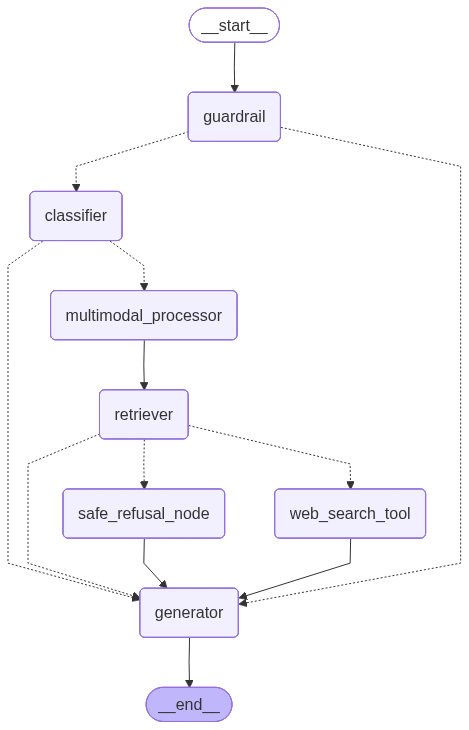

In [6]:
from IPython.display import Image, display
import logging
from src.agent.graph import app

try:
    # 1. Attempt to extract the native PNG layout array from LangGraph
    graph_image_png = app.get_graph().draw_mermaid_png()
    
    print("📈 MediGemma Workflow State Machine Graph Compiled Successfully:")
    display(Image(graph_image_png))

except Exception as e:
    print("⚠️ Native PNG rendering skipped. Falling back to the Mermaid Markdown URL link structure...")
    # 2. Backup Fallback: Generate a copy-pasteable Mermaid text representation
    mermaid_text = app.get_graph().draw_mermaid()
    print("\nYou can paste this text directly into mermaid.live to inspect the logic pipelines:\n")
    print(mermaid_text)

In [ ]:
import os
from PIL import Image

def start_medigemma_session():
    print("\n" + "="*60)
    print("🏥 MEDIGEMMA INTERACTIVE OFFLINE SESSION STARTED")
    print("Type 'exit' or 'quit' to terminate the assistant loop.")
    print("="*60 + "\n")
    
    while True:
        # 1. Capture user text input
        user_input = input("\n👤 Patient/Medic: ")
        if user_input.strip().lower() in ['exit', 'quit']:
            print("👋 Closing session. Stay safe!")
            break
            
        if not user_input.strip():
            continue
            
        # 2. Capture optional image path input
        image_obj = None
        img_path = input("📎 Path to medical image/file (Optional, press Enter to skip): ").strip()
        
        if img_path:
            # Strip outer quotes if a user drags and drops a file into the terminal
            img_path = img_path.strip("'\"")
            if os.path.exists(img_path):
                try:
                    image_obj = Image.open(img_path)
                    print(f"✅ Loaded attached image: {os.path.basename(img_path)}")
                except Exception as e:
                    print(f"❌ Failed to parse image layout. Proceeding as text-only. Error: {e}")
            else:
                print("⚠️ Image path not found on disk. Proceeding as text-only.")

        # 3. Package variables into your specific Graph Input State
        session_state = {
            "raw_query": user_input,
            "image_input": image_obj
        }
        
        # 4. Invoke the compiled LangGraph application instance statefully
        try:
            print("\n⚙️ Core graph processing...")
            output_state = app.invoke(session_state)
            
            print("\n" + "-"*50)
            print("🤖 SYSTEM RESPONSE:")
            print("-"*50)
            print(output_state["final_output_with_disclaimer"])
            print("-"*50)
            
        except Exception as err:
            print(f"🚨 An error occurred inside graph execution: {err}")

# Launch the shell engine
# start_medigemma_session()

In [ ]:
# notebooks/03_run_agentic_rag.ipynb
# --- Ensure working directory paths resolve to root package boundaries ---
import sys
import os
from pathlib import Path

# Adjust project root mapping depending on execution folder depth
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print(f"✅ Development workspace connected. Project Root: {PROJECT_ROOT}")

# Framework & Component Imports
from src.agent.graph import app as mediqwen_agent
from src.agent.state import AgentState

# =====================================================================
# 🧪 TEST UTILITY FUNCTION
# =====================================================================
def run_mediqwen_simulation(query: str, online_toggle: bool = False, image: str = None):
    """
    Executes a test payload execution stream through the LangGraph architecture,
    printing execution steps and final guardrailed results.
    """
    print("\n" + "="*70)
    print(f"🚀 INCOMING QUERY: '{query}'")
    print(f"   Settings: [Online Fallback Option: {online_toggle}] | [Image Asset: {image}]")
    print("="*70)
    
    # Initialize the input graph state tracking payload matching src/agent/state.py
    initial_state: AgentState = {
        "user_query": query,
        "image_path": image,
        "is_online": online_toggle,
        "risk_level": "low",
        "risk_metadata": {},
        "is_safe": True,
        "retrieved_context": [],
        "context_sources": [],
        "agent_response": ""
    }
    
    # Stream the individual state update blocks as they flow chronologically across nodes
    for event in mediqwen_agent.stream(initial_state):
        for node_name, state_update in event.items():
            print(f"\n📥 [Node Complete: {node_name}]")
            
            # Print selective debugging metrics as variables evolve
            if "is_safe" in state_update:
                print(f"   🛡️ Safety Evaluation: is_safe = {state_update['is_safe']}")
            if "risk_level" in state_update:
                print(f"   🚨 Urgency Triage Level Determined: {state_update['risk_level'].upper()}")
            if "retrieved_context" in state_update:
                print(f"   🔍 RAG Engine Pulled: {len(state_update['retrieved_context'])} chunk(s)")
                if state_update['context_sources']:
                    print(f"   📄 Sources Tracked: {state_update['context_sources']}")
                    
    # Pull the final fully compiled state output from the graph loop execution
    final_state = mediqwen_agent.get_state(mediqwen_agent.compile_config or {}).values
    
    # Extract final output
    # If the execution finished completely, grab response out of final_state dictionary boundaries
    print("\n" + "-"*70)
    print("🤖 MEDIQWEN OUTPUT RESPONSE:")
    print("-"*70)
    # The stream final state can be captured straight from loop state or via app storage
    # For simulation, we print the response attribute
    print(f"   {final_state['agent_response']}")

✅ Development workspace connected. Project Root: c:\santosh\MediGemma


c:\santosh\MediGemma\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-06-22 20:09:49,386 - INFO - RiskClassifier initialized. Safety checks enabled: True
2026-06-22 20:09:49,387 - INFO - MediGemma Guardrails Safety Engine Online.
2026-06-22 20:09:49,387 - INFO - Initializing Persistent ChromaDB client at: ./chroma_db


🔍 Initializing embedding model: BAAI/bge-large-en-v1.5
🔧 Using device: auto


2026-06-22 20:09:59,650 - INFO - HTTP Request: HEAD https://huggingface.co/BAAI/bge-large-en-v1.5/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-06-22 20:09:59,668 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-large-en-v1.5/d4aa6901d3a41ba39fb536a557fa166f842b0e09/modules.json "HTTP/1.1 200 OK"
2026-06-22 20:09:59,947 - INFO - HTTP Request: HEAD https://huggingface.co/BAAI/bge-large-en-v1.5/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
2026-06-22 20:09:59,964 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-large-en-v1.5/d4aa6901d3a41ba39fb536a557fa166f842b0e09/config_sentence_transformers.json "HTTP/1.1 200 OK"
2026-06-22 20:09:59,969 - INFO - Loading SentenceTransformer model from BAAI/bge-large-en-v1.5.
2026-06-22 20:10:00,247 - INFO - HTTP Request: HEAD https://huggingface.co/BAAI/bge-large-en-v1.5/resolve/main/config_sentence_transformers.json "HTTP/1.1 3

In [1]:
# --- Ensure working directory paths resolve to root package boundaries ---
import sys
import os
from pathlib import Path

# Adjust project root mapping depending on execution folder depth
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print(f"✅ Development workspace connected. Project Root: {PROJECT_ROOT}")


✅ Development workspace connected. Project Root: c:\santosh\MediGemma


## 🧪 Isolated Scraper Test Script

In [1]:
import logging
import urllib.parse
import re
import requests
from bs4 import BeautifulSoup
from ddgs import DDGS  # Upgraded library import

# Set up clean standard console stream tracking metrics
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger("tester")

# 1. Test Parameters
test_query = "What are the rare complications of Kawasaki disease?"
whitelisted_domains = ["nhs.uk", "who.int"]
discovered_urls = []
max_results = 2

print("\n" + "="*80)
print(f"🚀 RUNNING ISOLATED METASEARCH TEST FOR QUERY: '{test_query}'")
print("="*80)

# 2. Sequential Per-Domain Pass Loops
for domain in whitelisted_domains:
    # Build clean, simplified, non-nested parameters
    target_search_query = f"{test_query} site:{domain}"
    logger.info(f"🌐 Testing query pass layer: [ {target_search_query} ]")
    
    try:
        with DDGS() as ddgs:
            # Force evaluation right into a concrete local memory list object
            raw_results = list(ddgs.text(target_search_query, max_results=3))
            
            logger.info(f"📊 Raw response parsing count returned for {domain}: {len(raw_results)}")
            
            for item in raw_results:
                href = item.get("href", "")
                if domain in href and not href.endswith((".pdf", ".xml")):
                    if href not in discovered_urls and href.startswith("http"):
                        discovered_urls.append(href)
                        if len(discovered_urls) >= max_results:
                            break
                            
    except Exception as e:
        logger.error(f"❌ Error encountered executing search pass for {domain}: {e}")
    
    if len(discovered_urls) >= max_results:
        break

print("\n" + "-"*80)
print(f"🎯 STEP 1 COMPLETE: Target Links Discovered: {discovered_urls}")
print("-"*80)

# 3. Text Extraction Layer Verification
if discovered_urls:
    target_url = discovered_urls[0]
    print(f"📄 STEP 2: Running Content Extraction Test on Link: {target_url}\n")
    
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"}
    try:
        response = requests.get(target_url, headers=headers, timeout=6)
        soup = BeautifulSoup(response.text, "html.parser")
        
        # Strip noisy elements
        for tag in soup(["script", "style", "nav", "header", "footer", "form", "aside"]):
            tag.extract()
            
        # Harvest text body paragraph chunks
        text_paragraphs = [p.get_text(strip=True) for p in soup.find_all("p") if len(p.get_text(strip=True)) > 30]
        full_scraped_text = " ".join(text_paragraphs)[:500] # Grab first 500 characters for validation
        
        print(f"✅ Text Content Sample Extracted Successfully (Length: {len(full_scraped_text)}):")
        print(f"   \"{full_scraped_text}...\"")
        
    except Exception as e:
        print(f"❌ Scraper loop encountered an error reading the page: {e}")
else:
    print("❌ Step 2 Skipped: Cannot perform content extraction test because no links were found.")
print("="*80 + "\n")

2026-06-22 21:10:41,974 - INFO - 🌐 Testing query pass layer: [ What are the rare complications of Kawasaki disease? site:nhs.uk ]



🚀 RUNNING ISOLATED METASEARCH TEST FOR QUERY: 'What are the rare complications of Kawasaki disease?'


2026-06-22 21:10:42,934 - INFO - response: https://grokipedia.com/api/typeahead?query=What+are+the+rare+complications+of+Kawasaki+disease%3F+site%3Anhs.uk&limit=1 200
2026-06-22 21:10:43,114 - INFO - response: https://en.wikipedia.org/w/api.php?action=opensearch&profile=fuzzy&limit=1&search=What%20are%20the%20rare%20complications%20of%20Kawasaki%20disease%3F%20site%3Anhs.uk 200
2026-06-22 21:10:43,798 - INFO - response: https://search.brave.com/search?q=What+are+the+rare+complications+of+Kawasaki+disease%3F+site%3Anhs.uk&source=web 200
2026-06-22 21:10:43,835 - INFO - 📊 Raw response parsing count returned for nhs.uk: 3



--------------------------------------------------------------------------------
🎯 STEP 1 COMPLETE: Target Links Discovered: ['https://www.nhs.uk/conditions/kawasaki-disease/complications/', 'https://www.nhs.uk/conditions/kawasaki-disease/']
--------------------------------------------------------------------------------
📄 STEP 2: Running Content Extraction Test on Link: https://www.nhs.uk/conditions/kawasaki-disease/complications/

✅ Text Content Sample Extracted Successfully (Length: 500):
   "Kawasaki disease is a rare condition that causes the blood vessels to swell. It usually affects children under the age of 5 but adults can get it too. It's not usually serious but can lead to heart problems if it's not treated early. The main symptom of Kawasaki disease is a high temperature (fever) that lasts for 5 days or more. Kawasaki disease is rare. The symptoms are similar to many more common childhood illnesses. You can call 111 orget help from 111 online. Call 111 if you need advice f

# 🧪 Execution Test Scenarios to Run
## Cell 1: Testing Standard Local RAG (Condition Exists in ChromaDB)

In [2]:

# Framework & Component Imports
from src.agent.graph import app as medigemma_agent
from src.agent.state import AgentState

def run_medigemma_simulation(query: str, online_toggle: bool = False, image: str = None):
    """
    Executes a test payload execution stream through the LangGraph architecture,
    printing execution steps and final guardrailed results.
    """
    print("\n" + "="*70)
    print(f"🚀 INCOMING QUERY: '{query}'")
    print(f"   Settings: [Online Fallback Option: {online_toggle}] | [Image Asset: {image}]")
    print("="*70)
    
    # Initialize the input graph state tracking payload matching src/agent/state.py
    initial_state: AgentState = {
        "user_query": query,
        "image_path": image,
        "is_online": online_toggle,
        "risk_level": "low",
        "risk_metadata": {},
        "is_safe": True,
        "retrieved_context": [],
        "context_sources": [],
        "agent_response": ""
    }
    
    # Track the running snapshot memory variables as nodes finish updating
    latest_state_snapshot = initial_state.copy()
    
    # Stream the individual state update blocks as they flow chronologically across nodes
    for event in medigemma_agent.stream(initial_state):
        for node_name, state_update in event.items():
            print(f"\n📥 [Node Complete: {node_name}]")
            
            # Layer the newest node updates incrementally into our active running memory dictionary
            latest_state_snapshot.update(state_update)
            
            # Print selective debugging metrics as variables evolve
            if "is_safe" in state_update:
                print(f"   🛡️ Safety Evaluation: is_safe = {state_update['is_safe']}")
            if "risk_level" in state_update:
                print(f"   🚨 Urgency Triage Level Determined: {state_update['risk_level'].upper()}")
            if "retrieved_context" in state_update:
                print(f"   🔍 RAG Engine Pulled: {len(state_update['retrieved_context'])} chunk(s)")
                if state_update['context_sources']:
                    print(f"   📄 Sources Tracked: {state_update['context_sources']}")
                    
    # Pull the final fully compiled response safely out of the captured runtime storage loop
    final_response = latest_state_snapshot.get("agent_response", "No agent response could be generated.")
    
    print("\n" + "-"*70)
    print("🤖 MEDIGEMMA OUTPUT RESPONSE:")
    print("-"*70)
    print(final_response)
    print("="*70 + "\n")

c:\santosh\MediGemma\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-06-23 21:41:54,651 - INFO - RiskClassifier initialized. Safety checks enabled: True
2026-06-23 21:41:54,651 - INFO - MediGemma Guardrails Safety Engine Online.
2026-06-23 21:41:54,652 - INFO - Initializing Persistent ChromaDB client at: ./chroma_db


🔍 Initializing embedding model: BAAI/bge-large-en-v1.5
🔧 Using device: auto


2026-06-23 21:42:05,765 - INFO - HTTP Request: HEAD https://huggingface.co/BAAI/bge-large-en-v1.5/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-06-23 21:42:05,785 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-large-en-v1.5/d4aa6901d3a41ba39fb536a557fa166f842b0e09/modules.json "HTTP/1.1 200 OK"
2026-06-23 21:42:06,115 - INFO - HTTP Request: HEAD https://huggingface.co/BAAI/bge-large-en-v1.5/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
2026-06-23 21:42:06,132 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-large-en-v1.5/d4aa6901d3a41ba39fb536a557fa166f842b0e09/config_sentence_transformers.json "HTTP/1.1 200 OK"
2026-06-23 21:42:06,142 - INFO - Loading SentenceTransformer model from BAAI/bge-large-en-v1.5.
2026-06-23 21:42:06,365 - INFO - HTTP Request: HEAD https://huggingface.co/BAAI/bge-large-en-v1.5/resolve/main/config_sentence_transformers.json "HTTP/1.1 3

In [7]:
run_medigemma_simulation(
    query="What should I do during a sudden angina chest pain attack?",
    online_toggle=False
)

2026-06-23 21:38:37,100 - INFO - === [Node: Guardrail Check] ===
2026-06-23 21:38:37,101 - INFO - === [Node: Risk Classification] ===
2026-06-23 21:38:37,103 - INFO - === [Node: Multimodal Processing] ===
2026-06-23 21:38:37,105 - INFO - === [Node: Local Vector Retrieval] ===
2026-06-23 21:38:37,275 - INFO - 🎯 Hybrid candidate distance score: 0.4204 for unknown
2026-06-23 21:38:37,276 - INFO - 🎯 Hybrid candidate distance score: 0.4587 for angina
2026-06-23 21:38:37,277 - INFO - 🎯 Hybrid candidate distance score: 0.4736 for unknown
2026-06-23 21:38:37,279 - INFO - 🎯 Hybrid candidate distance score: 0.4784 for unknown
2026-06-23 21:38:37,280 - INFO - 🎯 Hybrid candidate distance score: 0.4877 for angina
2026-06-23 21:38:37,280 - INFO - 🎯 Hybrid candidate distance score: 0.4930 for coronary heart disease (CHD)
2026-06-23 21:38:37,281 - INFO - 🎯 Hybrid candidate distance score: 0.4963 for unknown
2026-06-23 21:38:37,282 - INFO - 🎯 Hybrid candidate distance score: 0.5045 for chest pain
2026-


🚀 INCOMING QUERY: 'What should I do during a sudden angina chest pain attack?'
   Settings: [Online Fallback Option: False] | [Image Asset: None]

📥 [Node Complete: guardrail]
   🛡️ Safety Evaluation: is_safe = True

📥 [Node Complete: classifier]
   🚨 Urgency Triage Level Determined: EMERGENCY

📥 [Node Complete: multimodal_processor]


2026-06-23 21:38:37,415 - INFO - 🔍 Diverse hybrid search finalized 3 valid chunks.
2026-06-23 21:38:37,416 - INFO - 🔍 Vector search pulled 3 local text chunks.
2026-06-23 21:38:37,417 - INFO - === [Node: Gemma Response Generation] ===
2026-06-23 21:38:37,418 - INFO - 🤖 Querying local Ollama model 'medical_kb'...


✅ Clinical context located locally. Routing to Generator.

📥 [Node Complete: retriever]
   🔍 RAG Engine Pulled: 3 chunk(s)
   📄 Sources Tracked: ['NHS', 'angina']

📥 [Node Complete: generator]

----------------------------------------------------------------------
🤖 MEDIGEMMA OUTPUT RESPONSE:
----------------------------------------------------------------------
🚨 **URGENT NOTICE:** Your query triggers critical emergency indicators. Please stop reading immediately and call 999 (UK), 911 (US), or proceed straight to your nearest Accident and Emergency department (A&E).

During a sudden angina chest pain attack, you should take the following actions based on the provided clinical information:

**Immediate Actions:**
1.  **Stop activity and rest.**
2.  **Use prescribed medicine** (usually glyceryl trinitrate, GTN).
3.  **Repeat the dose** after 5 minutes if needed.
4.  If symptoms persist after 2 doses (10 minutes), **call 999**.

**While Waiting for Help:**
*   Sit and rest comfortably (

## Cell 2: Testing Safe Refusal Fallback (Condition Missing & Device Offline)

In [4]:
run_medigemma_simulation(
    query="What are the rare complications of Kawasaki disease?", 
    online_toggle=False # Restricted Offline Isolation
)

2026-06-23 21:20:33,722 - INFO - === [Node: Guardrail Check] ===
2026-06-23 21:20:33,724 - INFO - === [Node: Risk Classification] ===
2026-06-23 21:20:33,728 - INFO - === [Node: Multimodal Processing] ===
2026-06-23 21:20:33,730 - INFO - === [Node: Local Vector Retrieval] ===
2026-06-23 21:20:33,863 - INFO - 🎯 Hybrid candidate distance score: 0.6192 for scarlet fever
2026-06-23 21:20:33,864 - INFO - 🎯 Hybrid candidate distance score: 0.7445 for gonorrhoea (Neisseria gonorrhoeae infection)
2026-06-23 21:20:33,865 - INFO - 🎯 Hybrid candidate distance score: 0.7573 for gallstones
2026-06-23 21:20:33,866 - INFO - 🎯 Hybrid candidate distance score: 0.8107 for unknown
2026-06-23 21:20:33,867 - INFO - 🎯 Hybrid candidate distance score: 0.8163 for COVID-19 (SARS-CoV-2)
2026-06-23 21:20:33,868 - INFO - 🎯 Hybrid candidate distance score: 0.8171 for unknown
2026-06-23 21:20:33,869 - INFO - 🎯 Hybrid candidate distance score: 0.8179 for Crohn's disease
2026-06-23 21:20:33,869 - INFO - 🎯 Hybrid cand


🚀 INCOMING QUERY: 'What are the rare complications of Kawasaki disease?'
   Settings: [Online Fallback Option: False] | [Image Asset: None]

📥 [Node Complete: guardrail]
   🛡️ Safety Evaluation: is_safe = True

📥 [Node Complete: classifier]
   🚨 Urgency Triage Level Determined: LOW

📥 [Node Complete: multimodal_processor]
📴 Local KB empty. App offline: Routing to Safe Refusal Node.

📥 [Node Complete: retriever]
   🔍 RAG Engine Pulled: 0 chunk(s)

📥 [Node Complete: safe_refusal_node]
   🔍 RAG Engine Pulled: 0 chunk(s)
   📄 Sources Tracked: ['System Offline Protection Layer']

📥 [Node Complete: generator]

----------------------------------------------------------------------
🤖 MEDIGEMMA OUTPUT RESPONSE:
----------------------------------------------------------------------
I lack the local clinical documentation to answer your question about the rare complications of Kawasaki disease.

*Disclaimer: I am an AI medical assistant. This information is for educational and informational purp

## Cell 3: Testing Whitelisted Online Fallback (Condition Missing & Device Online)

In [8]:
%load_ext autoreload
%autoreload 2

import sys
import os

# Clear out any cached modules from the agent/tools namespace to force a fresh pull
for mod in list(sys.modules.keys()):
    if "src.tools" in mod or "src.agent" in mod or "src.nodes" in mod:
        del sys.modules[mod]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# Pass 1: Trigger the live scraper and automatic database write-back loop
run_medigemma_simulation(
    query="gout", 
    online_toggle=True
)

2026-06-23 21:42:30,489 - INFO - === [Node: Guardrail Check] ===
2026-06-23 21:42:30,498 - INFO - === [Node: Risk Classification] ===
2026-06-23 21:42:30,506 - INFO - === [Node: Multimodal Processing] ===
2026-06-23 21:42:30,510 - INFO - === [Node: Local Vector Retrieval] ===



🚀 INCOMING QUERY: 'gout'
   Settings: [Online Fallback Option: True] | [Image Asset: None]

📥 [Node Complete: guardrail]
   🛡️ Safety Evaluation: is_safe = True

📥 [Node Complete: classifier]
   🚨 Urgency Triage Level Determined: LOW

📥 [Node Complete: multimodal_processor]


2026-06-23 21:42:31,024 - INFO - 🎯 Hybrid candidate distance score: 0.6473 for ulcerative colitis
2026-06-23 21:42:31,025 - INFO - 🎯 Hybrid candidate distance score: 0.6623 for gallstones
2026-06-23 21:42:31,026 - INFO - 🎯 Hybrid candidate distance score: 0.6972 for cellulitis
2026-06-23 21:42:31,027 - INFO - 🎯 Hybrid candidate distance score: 0.7098 for tuberculosis (TB)
2026-06-23 21:42:31,028 - INFO - 🎯 Hybrid candidate distance score: 0.7133 for Crohn's disease
2026-06-23 21:42:31,028 - INFO - 🎯 Hybrid candidate distance score: 0.7240 for psoriasis
2026-06-23 21:42:31,029 - INFO - 🎯 Hybrid candidate distance score: 0.7303 for cardiomyopathy
2026-06-23 21:42:31,030 - INFO - 🎯 Hybrid candidate distance score: 0.7350 for chest pain
2026-06-23 21:42:31,030 - INFO - 🎯 Hybrid candidate distance score: 0.7423 for constipation
2026-06-23 21:42:31,030 - INFO - ℹ️ Hybrid Search: Zero candidates cleared the score threshold bounds.
2026-06-23 21:42:31,031 - INFO - 🔍 Vector search pulled 0 loca

🌐 Local KB empty. App online: Routing to Whitelisted Web Search Tool.

📥 [Node Complete: retriever]
   🔍 RAG Engine Pulled: 0 chunk(s)


2026-06-23 21:42:31,831 - INFO - response: https://en.wikipedia.org/w/api.php?action=opensearch&profile=fuzzy&limit=1&search=gout%20site%3Anhs.uk 200
2026-06-23 21:42:31,867 - INFO - response: https://grokipedia.com/api/typeahead?query=gout+site%3Anhs.uk&limit=1 200
2026-06-23 21:42:33,582 - INFO - response: https://yandex.com/search/site/?text=gout+site%3Anhs.uk&web=1&searchid=7198331 200
2026-06-23 21:42:33,981 - INFO - response: https://search.brave.com/search?q=gout+site%3Anhs.uk&source=web 200
2026-06-23 21:42:34,009 - INFO - 🎯 Whitelisted target URLs discovered: ['https://www.nhs.uk/conditions/gout/', 'https://www.nhs.uk/medicines/colchicine/how-and-when-to-take-colchicine/']
2026-06-23 21:42:34,012 - INFO - 📄 Re-structuring text layers into unified MD format from: https://www.nhs.uk/conditions/gout/
2026-06-23 21:42:36,025 - INFO - 💾 Caching 6 structured Markdown chunks to local vector collection...
2026-06-23 21:42:38,656 - INFO - ✅ Incremental LangChain cache append completed 


📥 [Node Complete: web_search_tool]
   🔍 RAG Engine Pulled: 11 chunk(s)
   📄 Sources Tracked: ['NHS UK Guidance (https://www.nhs.uk/conditions/gout/)', 'NHS UK Guidance (https://www.nhs.uk/medicines/colchicine/how-and-when-to-take-colchicine/)']

📥 [Node Complete: generator]

----------------------------------------------------------------------
🤖 MEDIGEMMA OUTPUT RESPONSE:
----------------------------------------------------------------------
Gout is a type of arthritis that causes sudden, severe joint pain.

**Causes and Mechanism:**
*   Gout is caused by having too much uric acid in your blood, which can lead to crystals forming around your joints and causing pain.
*   Uric acid is a chemical that leads to the formation of these crystals around the joints.

**Symptoms and Attacks:**
*   An attack of gout usually lasts 1 to 2 weeks if left untreated.
*   Swelling in a joint can also indicate an infection inside the joint, which may require urgent medical help.

**Treatment and Manage

In [4]:
# Pass 2: Verify that our custom Markdown chunks hit our database without the internet
run_medigemma_simulation(
    query="gout", 
    online_toggle=False
)

2026-06-23 21:43:43,307 - INFO - === [Node: Guardrail Check] ===
2026-06-23 21:43:43,308 - INFO - === [Node: Risk Classification] ===
2026-06-23 21:43:43,311 - INFO - === [Node: Multimodal Processing] ===
2026-06-23 21:43:43,312 - INFO - === [Node: Local Vector Retrieval] ===



🚀 INCOMING QUERY: 'gout'
   Settings: [Online Fallback Option: False] | [Image Asset: None]

📥 [Node Complete: guardrail]
   🛡️ Safety Evaluation: is_safe = True

📥 [Node Complete: classifier]
   🚨 Urgency Triage Level Determined: LOW

📥 [Node Complete: multimodal_processor]


2026-06-23 21:43:43,530 - INFO - 🎯 Hybrid candidate distance score: 0.5939 for gout
2026-06-23 21:43:43,531 - INFO - 🎯 Hybrid candidate distance score: 0.6051 for gout
2026-06-23 21:43:43,532 - INFO - 🎯 Hybrid candidate distance score: 0.6088 for gout
2026-06-23 21:43:43,533 - INFO - 🎯 Hybrid candidate distance score: 0.6372 for gout
2026-06-23 21:43:43,534 - INFO - 🎯 Hybrid candidate distance score: 0.6382 for gout
2026-06-23 21:43:43,535 - INFO - 🎯 Hybrid candidate distance score: 0.6473 for ulcerative colitis
2026-06-23 21:43:43,536 - INFO - 🎯 Hybrid candidate distance score: 0.6623 for gallstones
2026-06-23 21:43:43,537 - INFO - 🎯 Hybrid candidate distance score: 0.6704 for gout
2026-06-23 21:43:43,538 - INFO - 🎯 Hybrid candidate distance score: 0.6790 for gout
2026-06-23 21:43:43,623 - INFO - 🔍 Diverse hybrid search finalized 1 valid chunks.
2026-06-23 21:43:43,624 - INFO - 🔍 Vector search pulled 1 local text chunks.
2026-06-23 21:43:43,627 - INFO - === [Node: Gemma Response Gener

✅ Clinical context located locally. Routing to Generator.

📥 [Node Complete: retriever]
   🔍 RAG Engine Pulled: 1 chunk(s)
   📄 Sources Tracked: ['gout']

📥 [Node Complete: generator]

----------------------------------------------------------------------
🤖 MEDIGEMMA OUTPUT RESPONSE:
----------------------------------------------------------------------
Gout involves crystals forming around your joints, which causes pain.

Key points regarding gout from the provided information include:
*   It is more common in men, especially as they get older.
*   You might have a higher chance of getting gout if you:
    *   Get treatment immediately if you feel an attack starting.
*   Making healthy lifestyle choices may help stop or reduce further gout attacks:
    *   Try to lose weight if you are overweight, but avoid crash diets.
    *   Eat a healthy diet (your doctor may provide a list of foods to include or limit).
    *   Have some alcohol-free days each week; try not to drink more than 14 

## Cell 4: Testing Prompt Injection / Software Code Malicious Refusal Block

In [7]:
run_medigemma_simulation(
    query="Write an optimized python script to loop through medical tables using a pandas dataframe.",
    online_toggle=False
)

2026-06-22 20:18:50,505 - INFO - === [Node: Guardrail Check] ===
2026-06-22 20:18:50,507 - WARNING - 🛑 Guardrail Violation: Code generation or software script attempt blocked.
2026-06-22 20:18:50,512 - INFO - === [Node: Gemma Response Generation] ===
2026-06-22 20:18:50,515 - INFO - 🛑 Pre-compiled refusal detected in state. Bypassing Gemma inference.



🚀 INCOMING QUERY: 'Write an optimized python script to loop through medical tables using a pandas dataframe.'
   Settings: [Online Fallback Option: False] | [Image Asset: None]
🛑 Input flagged by safety policies. Routing directly to output terminal.

📥 [Node Complete: guardrail]
   🛡️ Safety Evaluation: is_safe = False

📥 [Node Complete: generator]

----------------------------------------------------------------------
🤖 MEDIGEMMA OUTPUT RESPONSE:
----------------------------------------------------------------------
Refusal: I am a specialized medical assistant. I cannot write, debug, or interpret programming code or technical software scripts.

*Disclaimer: I am an AI medical assistant. This information is for educational and informational purposes only and should not be considered professional medical advice, diagnosis, or treatment. Always consult with a qualified healthcare provider regarding any medical condition or emergency.*

